In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
import warnings
%matplotlib inline
warnings.filterwarnings('ignore')
pd.options.display.max_columns = 99
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

In [ ]:
df = pd.read_csv("/content/Mall_Customers.csv")

In [ ]:
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [ ]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [ ]:
df.shape

(200, 5)

In [ ]:
df.isnull().sum()

,0
CustomerID,0
Genre,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


In [ ]:
df.columns

Index(['CustomerID', 'Genre', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')

In [ ]:
LE = LabelEncoder()
df['Genre'] = LE.fit_transform(df['Genre'])

In [ ]:
df['Genre']

,Genre
0,1
1,1
2,0
3,0
4,0
...,...
195,0
196,0
197,1
198,1


In [ ]:
X = df.iloc[:,:]

In [ ]:
pca = PCA(n_components=2,random_state=42)
X_pca = pca.fit_transform(X)

In [ ]:
X_pca

array([[-1.09383941e+02, -5.47845404e+00],
       [-1.08202857e+02,  3.49317649e+01],
       [-1.07376292e+02, -3.78408717e+01],
       [-1.06007807e+02,  3.05626965e+01],
       [-1.04980323e+02, -7.29674715e+00],
       [-1.03774723e+02,  2.98012381e+01],
       [-1.02996481e+02, -4.13227699e+01],
       [-1.01426745e+02,  4.70713035e+01],
       [-1.00952191e+02, -5.09237382e+01],
       [-9.93805223e+01,  2.40346077e+01],
       [-9.90706564e+01, -4.09178725e+01],
       [-9.74040858e+01,  4.91523683e+01],
       [-9.67777825e+01, -3.78938689e+01],
       [-9.52523148e+01,  3.02508027e+01],
       [-9.48417033e+01, -3.50274282e+01],
       [-9.34009908e+01,  3.26452221e+01],
       [-9.24499251e+01, -1.31741290e+01],
       [-9.12420152e+01,  2.04349779e+01],
       [-8.99471970e+01, -2.29456992e+01],
       [-8.84752130e+01,  4.81072460e+01],
       [-8.75736418e+01, -1.32190190e+01],
       [-8.63488497e+01,  2.60551150e+01],
       [-8.56046385e+01, -4.49591024e+01],
       [-8.

In [ ]:
pca.explained_variance_ratio_.cumsum()[1]

np.float64(0.9606357292871247)

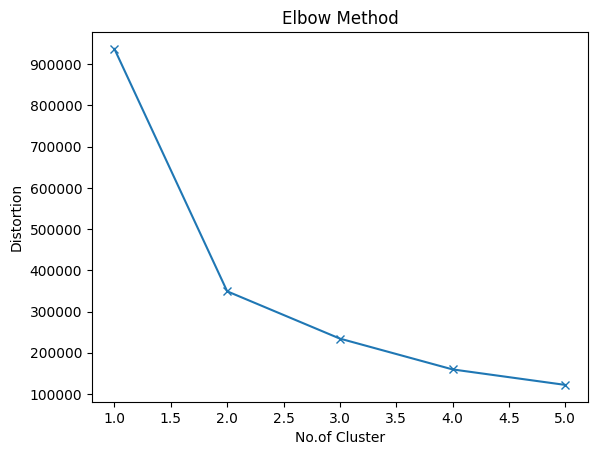

In [ ]:
distortion = []
for i in range(1,6):
  km = KMeans(n_clusters=i,init='k-means++',random_state=42,n_init=10)
  km.fit(X_pca)
  distortion.append(km.inertia_)
plt.plot(range(1,6),distortion,marker = 'x')
plt.xlabel("No.of Cluster")
plt.ylabel("Distortion")
plt.title("Elbow Method")
plt.show()

In [ ]:
model = KMeans(n_clusters = 3,init = 'k-means++',random_state=42,n_init = 10)
y = model.fit_predict(X_pca)

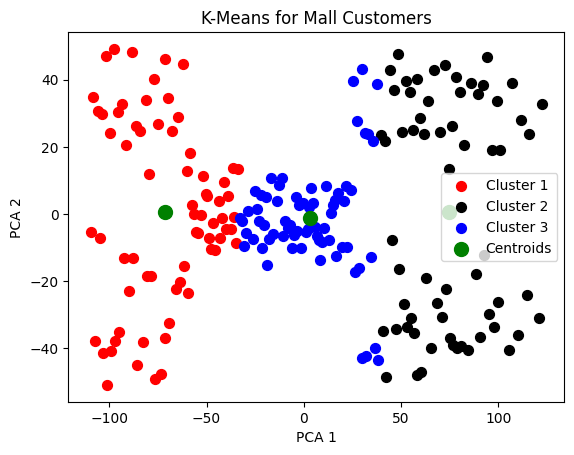

In [ ]:
plt.scatter(X_pca[y==0,0],X_pca[y==0,1],s=50,c='red',label='Cluster 1')
plt.scatter(X_pca[y==1,0],X_pca[y==1,1],s=50,c='black',label='Cluster 2')
plt.scatter(X_pca[y==2,0],X_pca[y==2,1],s=50,c='blue',label='Cluster 3')
plt.scatter(model.cluster_centers_[:,0],model.cluster_centers_[:,1],s=100,c='green',label='Centroids')
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("K-Means for Mall Customers")
plt.legend()
plt.show()